# Написание функций для работы с sqlite с использованием python

In [15]:
%load_ext sql
%sql sqlite:///base.db

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [16]:
#список стран
countries = ["Afghanistan", "Albania", "Algeria", "Andorra", "Angola", "Anguilla", "Argentina", "Armenia", "Aruba", "Australia", "Austria", "Azerbaijan", "Bahamas", "Bahrain", "Bangladesh",
             "Barbados", "Belarus", "Belgium", "Belize", "Benin", "Bermuda", "Bhutan", "Bolivia", "Bosnia and Herzegovina", "Botswana", "Brazil", "Bulgaria", "Burkina Faso", "Burundi", "Cambodia",
             "Cameroon", "Canada", "Central African Republic", "Chad", "Chile", "China", "Colombia", "Comoros", "Congo", "Costa Rica", "Cote d'Ivoire", "Croatia", "Cuba", "Cyprus", "Czech Republic",
             "Denmark", "Djibouti", "Dominica", "Dominican Republic", "Ecuador", "Egypt", "Eritrea", "Estonia", "Ethiopia", "Fiji", "Finland", "France", "Gabon", "Gambia", "Georgia", "Germany", "Ghana",
             "Greece", "Greenland", "Grenada", "Guadeloupe", "Guam", "Guatemala", "Guinea", "Guinea-Bissau", "Guyana", "Haiti", "Honduras", "Hong Kong", "Hungary", "Iceland", "India", "Indonesia", "Iran",
             "Iraq", "Ireland", "Isle of Man", "Israel", "Italy", "Jamaica", "Japan", "Jersey", "Jordan", "Kazakhstan", "Kenya", "Kiribati", "Kuwait", "Latvia", "Lebanon", "Lesotho", "Liberia", "Lithuania",
             "Luxembourg", "Macao", "Macedonia", "Madagascar", "Malawi", "Malaysia", "Maldives", "Mali", "Malta", "Martinique", "Mauritania", "Mauritius", "Mayotte", "Mexico", "Micronesia", "Moldova",
             "Monaco", "Mongolia", "Montenegro", "Montserrat", "Morocco", "Mozambique", "Myanmar", "Namibia", "Nauru", "Nepal", "Netherlands", "New Zealand", "Nicaragua", "Niger", "Nigeria", "Norway", "Oman",
             "Pakistan", "Palau", "Palestinian Territory", "Panama", "Papua New Guinea", "Paraguay", "Peru", "Philippines", "Poland", "Portugal", "Puerto Rico", "Qatar", "Republic of Korea", "Romania",
             "Russian Federation", "Rwanda", "Saudi Arabia", "Senegal", "Serbia", "Singapore", "Slovakia", "Slovenia", "Solomon Islands", "South Africa", "Spain", "Sudan", "Swaziland", "Sweden", "Switzerland",
             "Syrian Arab Republic", "Tajikistan", "Tanzania", "Thailand", "Timor-Leste", "Togo", "Tokelau", "Tonga", "Tunisia", "Turkey", "Turkmenistan", "Tuvalu", "Uganda", "Ukraine", "United Arab Emirates",
             "United Kingdom", "United States of America", "Uruguay", "Uzbekistan", "Vanuatu", "Venezuela", "Vietnam", "Yemen", "Zambia", "Zimbabwe"]

Лабораторная посвящена базе данных, связанной со спортивными командами. Схема расположена на картинке ниже.

## Схема
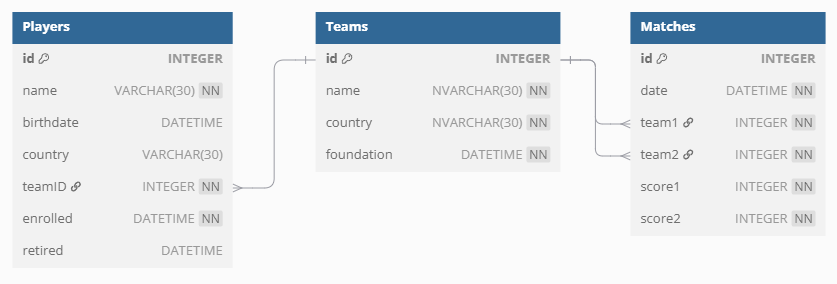

Foundation - дата основания

**Имя команды сделать unique**

# Задание 1
Реализовать таблицы со связями по схеме выше. Добавьте несколько команд и матчей между ними (через INSERT).

In [17]:
import sqlite3
connection = sqlite3.connect('base.db')
cur = connection.cursor()

In [18]:
cur.executescript("""
    DROP TABLE IF EXISTS Teams;
    DROP TABLE IF EXISTS Players;
    DROP TABLE IF EXISTS Matches;

    CREATE TABLE IF NOT EXISTS Teams (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        name TEXT NOT NULL UNIQUE,
        country TEXT NOT NULL,
        foundation DATETIME NOT NULL
    );

    CREATE TABLE IF NOT EXISTS Players (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        name TEXT NOT NULL,
        birthdate DATETIME,
        country TEXT,
        teamID INTEGER NOT NULL,
        enrolled DATETIME NOT NULL,
        retired DATETIME,
        FOREIGN KEY(teamID) REFERENCES Teams(id)
    );

    CREATE TABLE IF NOT EXISTS Matches (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        team1 INTEGER NOT NULL,
        team2 INTEGER NOT NULL,
        date DATETIME NOT NULL,
        score1 INTEGER NOT NULL,
        score2 INTEGER NOT NULL,
        FOREIGN KEY(team1) REFERENCES Teams(id),
        FOREIGN KEY(team2) REFERENCES Teams(id)
    );
""")

connection.commit()

In [19]:

cur.executescript("""
    INSERT INTO Teams (name, country, foundation) VALUES ('A', 'Spain', '1899-11-29');
    INSERT INTO Teams (name, country, foundation) VALUES ('B', 'Spain', '1902-03-06');
    INSERT INTO Teams (name, country, foundation) VALUES ('C', 'England', '1878-03-05');
    INSERT INTO Teams (name, country, foundation) VALUES ('D', 'England', '1892-03-15');
    INSERT INTO Teams (name, country, foundation) VALUES ('E', 'Germany', '1900-02-27');
    INSERT INTO Teams (name, country, foundation) VALUES ('F', 'France', '1970-08-12');

    INSERT INTO MATCHES (team1, team2, date, score1, score2) VALUES (1, 2, '2023-10-01', 3, 1);
    INSERT INTO MATCHES (team1, team2, date, score1, score2) VALUES (3, 4, '2023-10-02', 2, 2);
    INSERT INTO MATCHES (team1, team2, date, score1, score2) VALUES (5, 6, '2023-10-03', 4, 0);
    INSERT INTO MATCHES (team1, team2, date, score1, score2) VALUES (1, 3, '2023-10-04', 1, 1);
    INSERT INTO MATCHES (team1, team2, date, score1, score2) VALUES (2, 4, '2023-10-05', 0, 0);
    INSERT INTO MATCHES (team1, team2, date, score1, score2) VALUES (5, 1, '2023-10-06', 2, 3);
    INSERT INTO MATCHES (team1, team2, date, score1, score2) VALUES (6, 3, '2023-10-07', 1, 2);
    INSERT INTO MATCHES (team1, team2, date, score1, score2) VALUES (4, 5, '2023-10-08', 0, 1);
    INSERT INTO MATCHES (team1, team2, date, score1, score2) VALUES (2, 6, '2023-10-09', 3, 4);
    INSERT INTO MATCHES (team1, team2, date, score1, score2) VALUES (1, 4, '2023-10-10', 2, 2);
    INSERT INTO MATCHES (team1, team2, date, score1, score2) VALUES (3, 5, '2023-10-11', 1, 0);
    INSERT INTO MATCHES (team1, team2, date, score1, score2) VALUES (2, 1, '2023-10-12', 0, 1);
    INSERT INTO MATCHES (team1, team2, date, score1, score2) VALUES (6, 4, '2023-10-13', 2, 0);
""")

connection.commit()

# Задание 2

Написать функцию, осуществляющую добавление нового игрока в таблицу игроков.

На входе имя, дата рождения, страна, **имя команды**, дата перехода в команду, дата увольнения (необязательный параметр). Предусмотреть различные ошибки (такие как неверное название команды (игрока нельзя добавить, если его команды нет в таблице команд), возраст < 0 и т.п.)

После написания функции необходимо добавить несколько игроков.

In [ ]:
from datetime import datetime

def insert_player(name, birthdate, country, team_name, enrolled, retired=None):
    if country not in countries:
        raise ValueError(f"Country '{country}' is not in the list.")

    cur.execute(f"SELECT id, foundation FROM Teams WHERE name = ?", (team_name,))
    team = cur.fetchone()
    
    if team is None:
        raise ValueError(f"Team '{team_name}' does not exist.")
    
    foundation = datetime.strptime(team[1], '%Y-%m-%d')

    if datetime.strptime(birthdate, '%Y-%m-%d') > datetime.now():
        raise ValueError("Invalid birthdate (later than today).")

    if datetime.strptime(enrolled, '%Y-%m-%d') > datetime.now():
        raise ValueError("Invalid enrollment date (later than today).")

    if retired is not None and datetime.strptime(retired, '%Y-%m-%d') > datetime.now():
        raise ValueError("Invalid retirement date (later than today).")
    
    if retired is not None and datetime.strptime(retired, '%Y-%m-%d') < datetime.strptime(enrolled, '%Y-%m-%d'):
        raise ValueError("Retirement date must be after enrollment date.")

    if datetime.strptime(enrolled, '%Y-%m-%d') < foundation:
        raise ValueError("Invalid enrollment date (earlier than team foundation date).")
    
    if retired is not None and datetime.strptime(enrolled, '%Y-%m-%d') > datetime.strptime(retired, '%Y-%m-%d'):
        raise ValueError("Invalid enrollment date (later than retirement date).")

    cur.execute("INSERT INTO Players (name, birthdate, country, teamID, enrolled, retired) VALUES (?, ?, ?, ?, ?, ?)",
                (name, birthdate, country, team[0], enrolled, retired,))
    connection.commit()

In [21]:
insert_player('Player A', '1987-06-24', 'Argentina', 'A', '2004-10-16', '2020-08-01')
insert_player('Player B', '1985-02-05', 'Portugal', 'A', '2003-08-16', '2012-07-15')
insert_player('Player C', '1992-02-05', 'Brazil', 'C', '2013-08-03')
insert_player('Player D', '1998-12-20', 'France', 'B', '2017-08-31', '2021-07-15')
insert_player('Player E', '1972-06-23', 'France', 'D', '2001-07-09')
insert_player('Player F', '1977-08-17', 'France', 'E', '2007-07-25', '2015-06-30')
insert_player('Player G', '1984-05-11', 'Spain', 'B', '2002-08-17')
insert_player('Player H', '1985-05-11', 'France', 'D', '2002-08-17', '2010-06-30')

In [22]:
%%sql

SELECT * FROM Players;

Running query in 'sqlite:///base.db'

id,name,birthdate,country,teamID,enrolled,retired
1,Player A,1987-06-24,Argentina,1,2004-10-16,2020-08-01
2,Player B,1985-02-05,Portugal,1,2003-08-16,2012-07-15
3,Player C,1992-02-05,Brazil,3,2013-08-03,None
4,Player D,1998-12-20,France,2,2017-08-31,2021-07-15
5,Player E,1972-06-23,France,4,2001-07-09,None
6,Player F,1977-08-17,France,5,2007-07-25,2015-06-30
7,Player G,1984-05-11,Spain,2,2002-08-17,None
8,Player H,1985-05-11,France,4,2002-08-17,2010-06-30


# Задание 3
Написать функцию player_stat, которая получает на вход имя игрока и выдает количество побед, ничей и поражений этого игрока (учитывать, что до и после найма игрока успехи его команды не учитываются).
Вывести статистику по игрокам.

In [23]:
def player_stat(player_name: str) -> tuple[int, int, int]:
    cur.execute("SELECT teamID, enrolled, retired FROM Players WHERE name = ?", (player_name,))
    player = cur.fetchone()
    if player is None:
        print(f"Player '{player_name}' does not exist.")
        return

    cur.execute("""
        SELECT t1.id, m.score1, m.score2
        FROM Matches m
        JOIN Teams t1 ON m.team1 = t1.id
        JOIN Teams t2 ON m.team2 = t2.id
        WHERE m.team1 = ? OR m.team2 = ? AND m.date >= ? AND (? IS NULL OR m.date <= ?)
    """, (player[0], player[0], player[1], player[2], player[2]))

    wins = 0
    losses = 0
    draws = 0
    matches = cur.fetchall()

    for match in matches:
        if match[1] > match[2]:
            if match[0] == player[0]:
                wins += 1
            else:
                losses += 1
        elif match[1] < match[2]:
            if match[0] == player[0]:
                losses += 1
            else:
                wins += 1
        else:
            draws += 1

    return (wins, losses, draws)

In [24]:
def player_list():
    cur.execute("SELECT name FROM Players")
    players = cur.fetchall()
    return [player[0] for player in players]

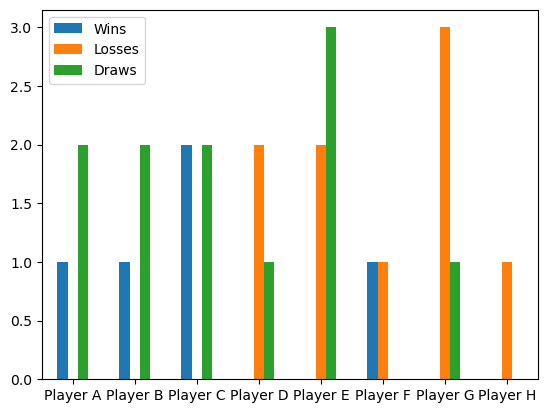

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

players = player_list()
stats = [player_stat(player) for player in players]

df = pd.DataFrame(stats, columns=['Wins', 'Losses', 'Draws'], index=players)
ax = df.plot.bar(rot=0)